# Cost-benefit calculations — Companies

This notebook applies the same cost-benefit pattern used in `09_costbenefit.ipynb` / `10_costbenefit_additional_measures.ipynb` (Schools) to the **Companies** asset type, now that it has been calibrated (see `06b_calibration_residential_companies.ipynb`).

Measures: Portable flood barriers for businesses, Business interruption insurance, Relocation of high-risk businesses, Levee protecting the commercial district, Elevated inventory storage for retailers, Business continuity & supply chain diversification.

All data and calculation steps mirror the Schools notebooks; the in-bar measure-name overlap on the cost-benefit chart, the missing legend on the return-period chart, and the waterfall arrow label overlap have already been fixed here (see FEEDBACK_measures_exercise.md).

In [1]:
from pathlib import Path

ENTITY_DIR = "../data/entity_files_adaptation/"
ENTITY_FILE = "Porto_Alegre_BRAZIL_Entity_Floods_Companies_calibrated_measures.xlsx"
entity_path = Path(ENTITY_DIR) / ENTITY_FILE

HAZARD_DIR = "../data/hazard/"
HAZARD_RETURN_PERIODS = [10, 20, 50, 100, 200, 500]
HAZARD_FILES = [f"PortoAlegre_RP{rp}_depth.tif" for rp in HAZARD_RETURN_PERIODS]
haz_paths = [Path(HAZARD_DIR) / f for f in HAZARD_FILES]

YEAR_PRESENT = 2025
YEAR_FUTURE = 2050

FUTURE_HAZARD_FREQUENCIES_PATH = "../data/hazard/porto_alegre_rp_mapping_2025_2050.csv"

### Create present-day and future Entity objects

In [2]:
import copy
from climada.entity import Entity, MeasureSet

entity_present = Entity.from_excel(entity_path)
entity_future = copy.deepcopy(entity_present)

entity_present.exposures.ref_year = YEAR_PRESENT
entity_present.exposures.value_unit = "USD"
entity_present.exposures.description = f"{YEAR_PRESENT} companies economic exposure"

entity_future.exposures.ref_year = YEAR_FUTURE
entity_future.exposures.value_unit = "USD"
entity_future.exposures.description = f"{YEAR_FUTURE} companies economic exposure"

ECONOMIC_GROWTH_RATE = 0.02
n_years = YEAR_FUTURE - YEAR_PRESENT
growth = (1 + ECONOMIC_GROWTH_RATE) ** n_years

new_gdf = entity_future.exposures.gdf
new_gdf["value"] = new_gdf["value"] * growth
entity_future.exposures.set_gdf(new_gdf)

print(f"Total value of exposures in {YEAR_PRESENT}: {entity_present.exposures.value.sum():,.2f} USD")
print(f"Total value of exposures in {YEAR_FUTURE}: {entity_future.exposures.value.sum():,.2f} USD")

Total value of exposures in 2025: 3,655,929,050.00 USD
Total value of exposures in 2050: 5,997,939,114.77 USD


### Create present-day and future hazard objects

In [3]:
import numpy as np
import pandas as pd
from climada.hazard import Hazard

def event_frequency_from_return_periods(return_periods):
    rp_rev = copy.deepcopy(return_periods)[::-1]
    exceedance_frequency = np.array([1/rp for rp in rp_rev])
    event_frequency = np.diff(np.concatenate([[0], exceedance_frequency]))
    event_frequency = event_frequency[::-1]
    return event_frequency

event_frequency_present = event_frequency_from_return_periods(HAZARD_RETURN_PERIODS)

haz_present = Hazard.from_raster(
    files_intensity = haz_paths,
    attrs={
        'unit': 'm',
        'event_name': [f'Return period {rp}' for rp in HAZARD_RETURN_PERIODS],
        'frequency': event_frequency_present
    },
    haz_type='FL'
)

future_rps_df = pd.read_csv(Path(FUTURE_HAZARD_FREQUENCIES_PATH))
assert future_rps_df["historical_return_period"].tolist() == HAZARD_RETURN_PERIODS, \
    "The return periods in the future frequencies file do not match the return periods of the hazard data"

future_rps = future_rps_df["future_return_period_2050"]
event_frequency_future = event_frequency_from_return_periods(future_rps)

haz_future = copy.deepcopy(haz_present)
haz_future.event_name = [f'Return period {rp}' for rp in future_rps]
haz_future.frequency = event_frequency_future

In [4]:
entity_present.exposures.assign_centroids(haz_present)
entity_future.exposures.assign_centroids(haz_future)

### Future variant of the relocation measure

The relocation measure swaps the Exposures for a pre-built HDF5 file. The present-day file holds 2025 values, but the future Entity's exposures include economic growth — pointing the future Entity's measure at the 2025 file would make the measure appear to 'remove' the growth too, overstating its benefit (see the equivalent fix for Schools in notebook 10 / FEEDBACK_measures_exercise.md). We already built both the present-day and 2050 relocated HDF5 files up front (see `scratch_build_relocated_companies.py`), so we only need to point the future Entity's measure at the 2050 file here.

In [5]:
MEASURE_RELOCATION = "Relocation of high-risk businesses"

entity_future.measures.get_measure("FL", MEASURE_RELOCATION).exposures_set = str(
    Path(ENTITY_DIR) / "Porto_Alegre_BRAZIL_Exposures_Companies_relocated_2050.hdf5"
)

from climada.entity import Exposures
relocated_future_check = Exposures.from_hdf5(
    Path(ENTITY_DIR) / "Porto_Alegre_BRAZIL_Exposures_Companies_relocated_2050.hdf5"
)
relocated_mask = (
    relocated_future_check.gdf["value"].values
    < entity_future.exposures.gdf["value"].values
)
print(f"{relocated_mask.sum()} exposure points relocated in the future variant")

20 exposure points relocated in the future variant


## Cost-Benefit calculation

We initialize a `CostBenefit` object and run the calculation with its `calc` method.

In [6]:
from climada.engine import CostBenefit
from climada.engine.cost_benefit import risk_aai_agg

costben = CostBenefit()
costben.calc(
    haz_present,
    entity_present,
    haz_future=haz_future,
    ent_future=entity_future,
    assign_centroids=False
)


Measure                                               Cost (USD m)    Benefit (USD m)    Benefit/Cost
--------------------------------------------------  --------------  -----------------  --------------
Portable flood barriers for businesses                     36.5325           147.182         4.02879
Business interruption insurance                           713.52             474.347         0.664798
Relocation of high-risk businesses                         10.25              13.5083        1.31788
Levee protecting the commercial district                   50                321.952         6.43903
Elevated inventory storage for retailers                   18.2662           165.785         9.07603
Business continuity & supply chain diversification         70                248.677         3.55254

--------------------  ---------  -------
Total climate risk:    828.925   (USD m)
Average annual risk:    49.6197  (USD m)
Residual risk:        -542.526   (USD m)
--------------------  -

In [7]:
names = entity_present.measures.get_names()["FL"]
assert len(names) == 6, f"Expected 6 measures, got {len(names)}: {names}"
assert all(name in costben.cost_ben_ratio for name in names), \
    "Missing cost_ben_ratio entry for some measure"
assert all(v == v for v in costben.benefit.values()), "Found NaN in benefits"  # v != v means NaN
print(f"{len(names)} measures present, no NaN benefits:", sorted(names))

6 measures present, no NaN benefits: ['Business continuity & supply chain diversification', 'Business interruption insurance', 'Elevated inventory storage for retailers', 'Levee protecting the commercial district', 'Portable flood barriers for businesses', 'Relocation of high-risk businesses']


## Visualizations

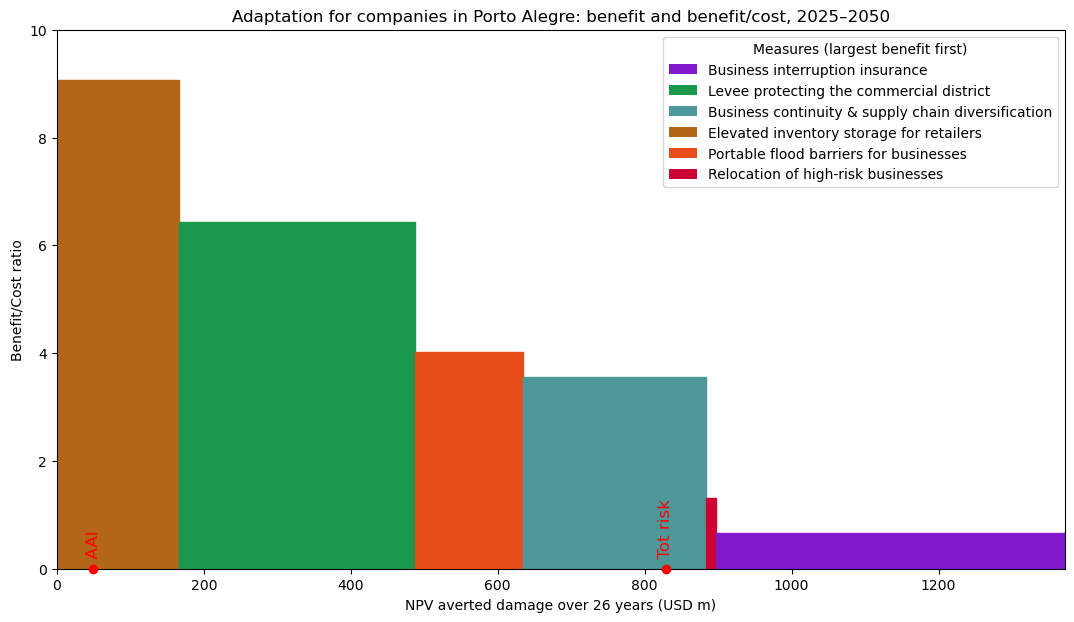

In [8]:
from pathlib import Path
from matplotlib.patches import Patch

OUTPUT_DIR = Path("../outputs/")
OUTPUT_DIR.mkdir(exist_ok=True)

ax = costben.plot_cost_benefit()
fig = ax.figure
fig.set_size_inches(13, 7)

# CLIMADA writes each measure's name vertically inside its bar — replace with
# a legend once there are enough measures for the labels to collide (see the
# equivalent fix for Schools, notebook 10). Labels are padded with leading
# spaces, so compare on the stripped text.
names = entity_present.measures.get_names()["FL"]
for text in list(ax.texts):
    if text.get_text().strip() in names:
        text.remove()

names_sorted = sorted(names, key=lambda n: costben.benefit[n], reverse=True)
handles = [
    Patch(
        facecolor=tuple(np.asarray(entity_present.measures.get_measure("FL", n).color_rgb)[:3]),
        label=n,
    )
    for n in names_sorted
]
ax.legend(handles=handles, loc="upper right", title="Measures (largest benefit first)")
ax.set_title("Adaptation for companies in Porto Alegre: benefit and benefit/cost, 2025\u20132050")
fig.savefig(OUTPUT_DIR / "brazil_companies_cost_benefit.png", dpi=420, bbox_inches="tight")

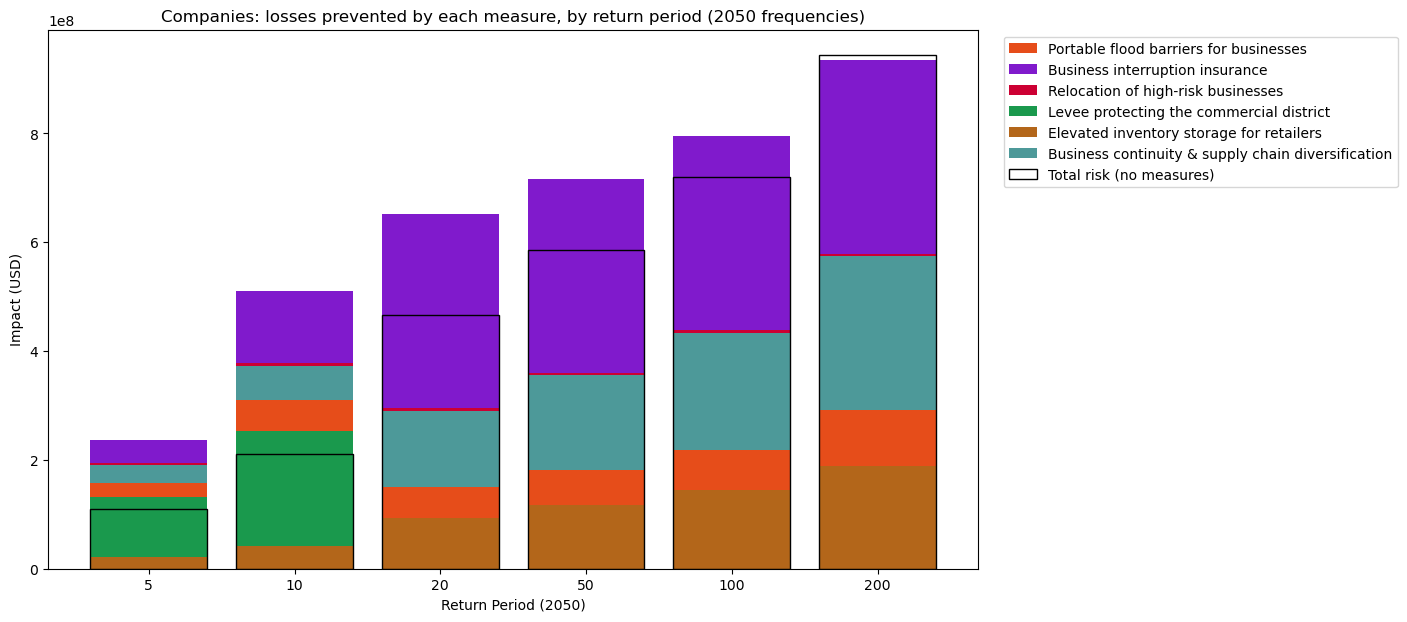

In [9]:
from matplotlib.patches import Patch

ax = costben.plot_event_view(return_per=future_rps)
fig = ax.figure
fig.set_size_inches(12, 7)

names = entity_present.measures.get_names()["FL"]
handles = [
    Patch(
        facecolor=tuple(np.asarray(entity_present.measures.get_measure("FL", n).color_rgb)[:3]),
        label=n,
    )
    for n in names
]
handles.append(Patch(facecolor="none", edgecolor="black", label="Total risk (no measures)"))
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.set_title("Companies: losses prevented by each measure, by return period (2050 frequencies)")
fig.savefig(OUTPUT_DIR / "brazil_companies_benefits_by_return_period.png", dpi=420, bbox_inches="tight")

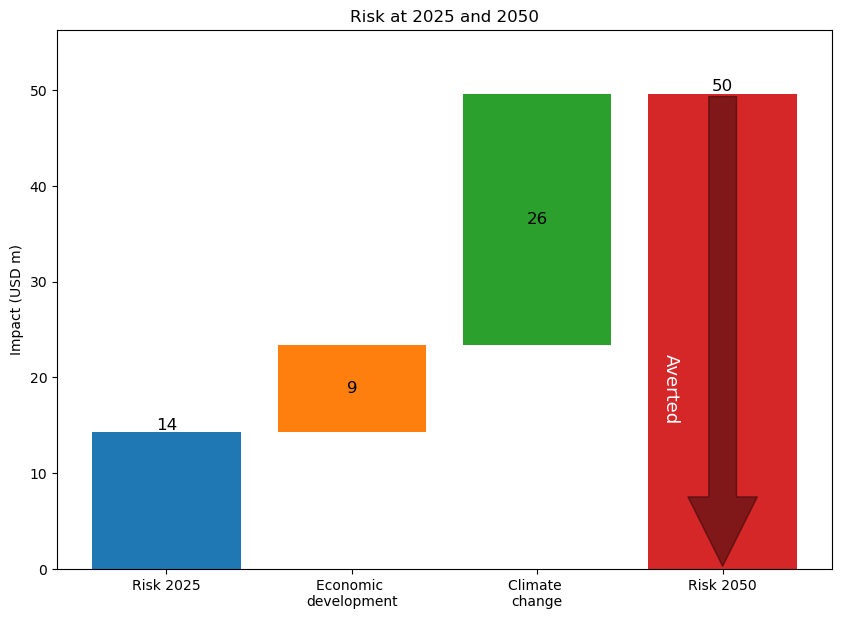

In [10]:
# Create a waterfall plot
ax = costben.plot_waterfall(
       haz_present, entity_present, haz_future, entity_future
    )

# Add an arrow showing averted risk
costben.plot_arrow_averted(
    axis=ax,
    in_meas_names=entity_present.measures.get_names()['FL'],
    accumulate=True,
    combine=False,
    risk_func=risk_aai_agg,
    disc_rates=None,
    imp_time_depen=1,
)

fig = ax.figure
fig.set_size_inches(10, 7)
ax.set_ylim(0, ax.get_ylim()[1] * 1.08)  # headroom so the bar value labels clear the arrow
for text in ax.texts:
    if text.get_text() == "Averted":
        text.set_position((text.get_position()[0] - 0.28, ax.get_ylim()[1] * 0.40))
        text.set_color("white")
        text.set_fontsize(13)
fig.savefig(OUTPUT_DIR / "brazil_companies_waterfall_averted_risk.png", dpi=420, bbox_inches="tight")

### Map for decision-makers

Expected annual impact per exposure point (2025, no adaptation), over a Porto Alegre basemap, to show where the risk is concentrated.

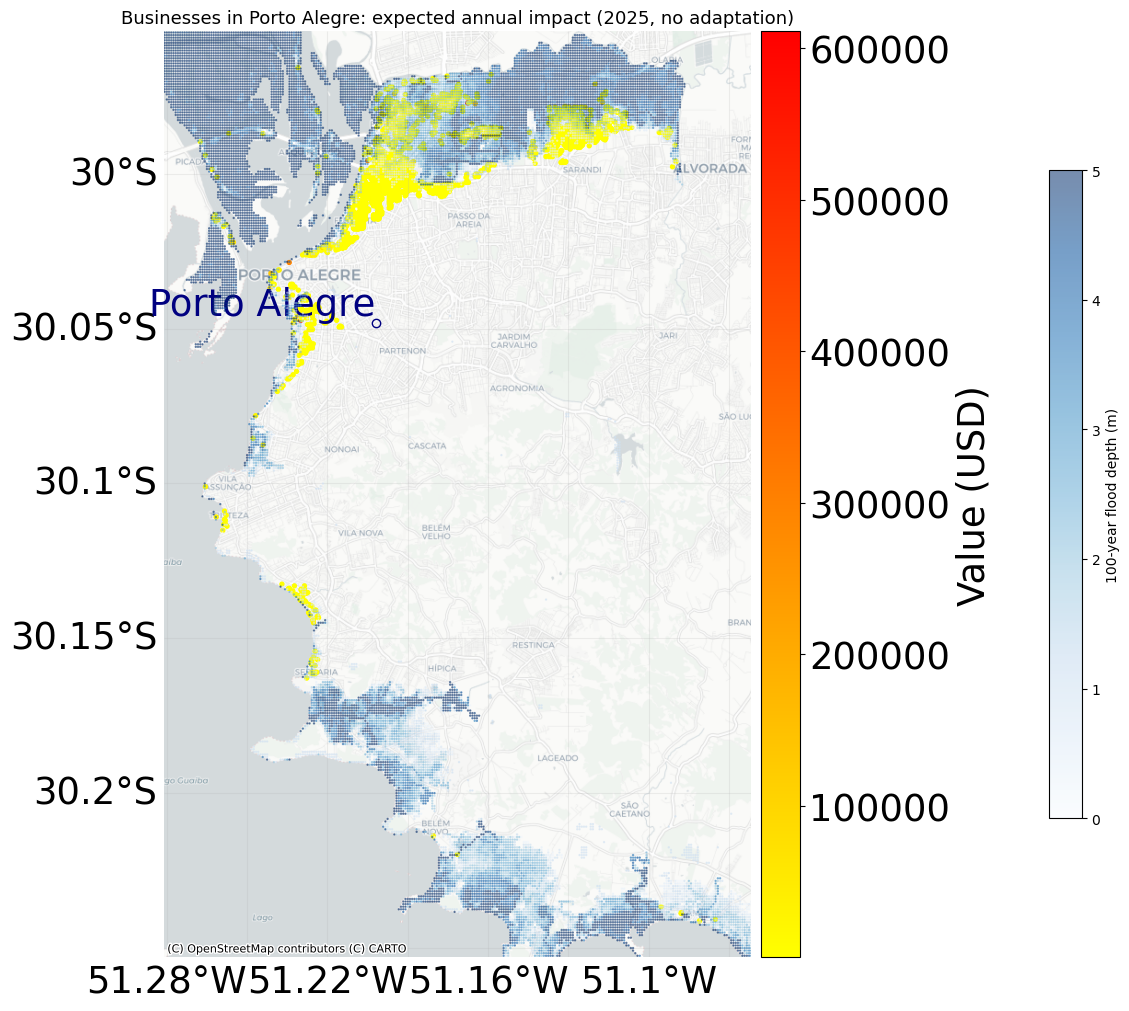

In [11]:
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from matplotlib.ticker import ScalarFormatter
from climada.engine import ImpactCalc

imp_present = ImpactCalc(
    entity_present.exposures, entity_present.impact_funcs, haz_present
).impact(save_mat=False, assign_centroids=False)

ax = imp_present.plot_basemap_eai_exposure(
    ignore_zero=True,
    buffer=1500,
    s=8,
    zoom=12,
    url=ctx.providers.CartoDB.Positron,
    cmap="autumn_r",
    figsize=(12, 10),
)

# The colorbar's automatic scientific-notation offset label (e.g. '1e6',
# placed just above the colorbar) collides with a long, centered title
# once values exceed 1e6. Force plain (non-scientific) tick labels instead
# of fighting the collision with title placement/size.
cbar_ax = ax.figure.axes[-1]
fmt = ScalarFormatter(useOffset=False)
fmt.set_scientific(False)
cbar_ax.yaxis.set_major_formatter(fmt)

# plot_basemap_eai_exposure() already calls ax.set_title(...) internally
# (at the default center position) -- calling set_title again at the same
# (default) position replaces it; passing loc='left' here instead would add
# a *second*, independent title slot that overlaps the first
ax.set_title("Businesses in Porto Alegre: expected annual impact (2025, no adaptation)", fontsize=13)

# Overlay the 100-year flood-depth 'mancha' on top of the EAI points (as
# with the relocation maps, the hazard patch is always drawn/kept above the
# exposure layer -- zorder=5 puts it above the EAI scatter's default zorder).
# `ax` here is a cartopy GeoAxes in Web Mercator (set up internally by
# plot_basemap_eai_exposure for the contextily basemap), so raw lon/lat
# values need transform=ccrs.PlateCarree() or they plot off in the corner
# near the projection's origin instead of over Porto Alegre.
rp100_idx = HAZARD_RETURN_PERIODS.index(100)
depth = haz_present.intensity[rp100_idx, :].toarray().flatten()
flooded = depth > 0.05
sc_depth = ax.scatter(
    haz_present.centroids.lon[flooded],
    haz_present.centroids.lat[flooded],
    c=depth[flooded], s=0.5, cmap="Blues",
    norm=mcolors.Normalize(0, 5), alpha=0.55, zorder=5,
    transform=ccrs.PlateCarree(),
)
plt.colorbar(sc_depth, ax=ax, shrink=0.7, pad=0.12, label="100-year flood depth (m)")

ax.figure.savefig(OUTPUT_DIR / "brazil_companies_map_expected_annual_impact.png", dpi=420, bbox_inches="tight")

### Map: relocation measure

100-year flood depth with all exposure points and the companies proposed for the relocation measure marked.

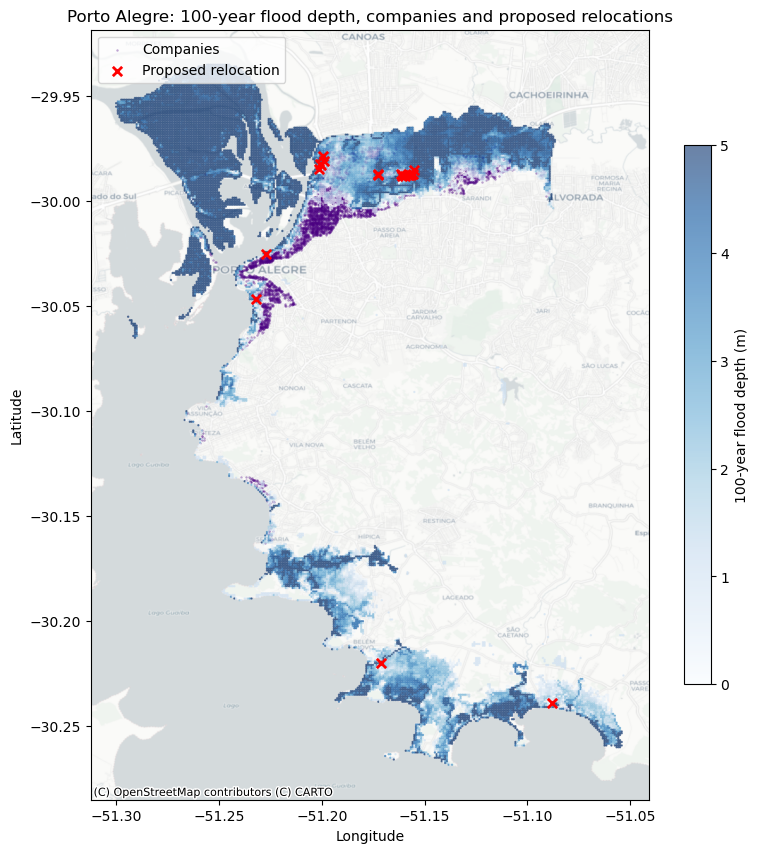

In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

rp100_idx = HAZARD_RETURN_PERIODS.index(100)
depth = haz_present.intensity[rp100_idx, :].toarray().flatten()
flooded = depth > 0.05

fig2, ax2 = plt.subplots(figsize=(9, 10))

# Draw order (and explicit zorder as a safety net): exposure points at the
# bottom, the flood-depth 'mancha' (hazard patch) above them so it always
# stays visible instead of being covered by dense exposure scatter, and the
# relocation markers on top of everything so they remain a clear call-out.
ax2.scatter(
    entity_present.exposures.longitude, entity_present.exposures.latitude,
    s=3, c="#4b0082", alpha=0.35, linewidths=0, zorder=1, label="Companies",
)

sc = ax2.scatter(
    haz_present.centroids.lon[flooded],
    haz_present.centroids.lat[flooded],
    c=depth[flooded], s=0.5, cmap="Blues",
    norm=mcolors.Normalize(0, 5), alpha=0.6, zorder=2,
)
plt.colorbar(sc, ax=ax2, shrink=0.7, label="100-year flood depth (m)")

ax2.scatter(
    entity_present.exposures.longitude[relocated_mask],
    entity_present.exposures.latitude[relocated_mask],
    s=45, c="red", marker="x", linewidths=2, zorder=3, label="Proposed relocation",
)
try:
    ctx.add_basemap(ax2, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron, zoom=12)
except Exception as err:
    print(f"Basemap unavailable ({err}); continuing without it")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.legend(loc="upper left")
ax2.set_title("Porto Alegre: 100-year flood depth, companies and proposed relocations")
fig2.savefig(OUTPUT_DIR / "brazil_companies_map_rp100_depth_relocation.png", dpi=420, bbox_inches="tight")

In [13]:
for f in [
    "brazil_companies_cost_benefit.png",
    "brazil_companies_benefits_by_return_period.png",
    "brazil_companies_waterfall_averted_risk.png",
    "brazil_companies_map_expected_annual_impact.png",
    "brazil_companies_map_rp100_depth_relocation.png",
]:
    size = (OUTPUT_DIR / f).stat().st_size
    assert size > 10_000, f"{f} looks too small ({size} bytes)"
    print(f"{f}: {size:,} bytes")

brazil_companies_cost_benefit.png: 318,390 bytes
brazil_companies_benefits_by_return_period.png: 302,106 bytes
brazil_companies_waterfall_averted_risk.png: 144,378 bytes
brazil_companies_map_expected_annual_impact.png: 7,493,834 bytes
brazil_companies_map_rp100_depth_relocation.png: 5,294,956 bytes
